In [46]:
import numpy as np
import os
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import models, transforms
import torch
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import pickle



In [23]:
BASE = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

data_path = os.path.join(BASE, "data")

no_defect = os.listdir(os.path.join(data_path, "KGT_noDefect"))
pitting= os.listdir(os.path.join(data_path, "KGT_pitting"))

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_7668/3320734019.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Folder', y='File Count', data=df, palette='Blues_d')


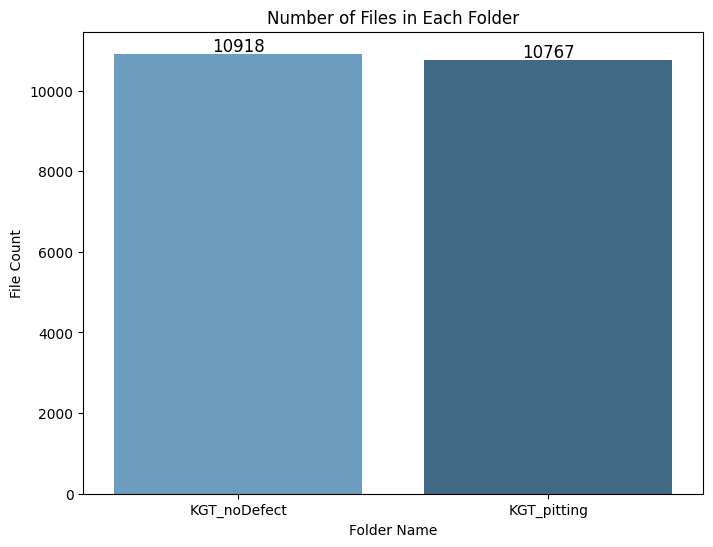

21685


In [24]:
df = pd.DataFrame({
    'Folder': ['KGT_noDefect', 'KGT_pitting'],
    'File Count': [len(no_defect), len(pitting)]
})

plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='Folder', y='File Count', data=df, palette='Blues_d')

plt.title('Number of Files in Each Folder')
plt.xlabel('Folder Name')
plt.ylabel('File Count')

for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='center', 
                      fontsize=12, color='black', 
                      xytext=(0, 5), textcoords='offset points')

plt.show()

sum = len(no_defect) + len(pitting)
print(sum)

In [25]:
img_path = os.path.join(data_path, "KGT_noDefect", no_defect[0])

img = Image.open(img_path)

img.mode

'RGB'

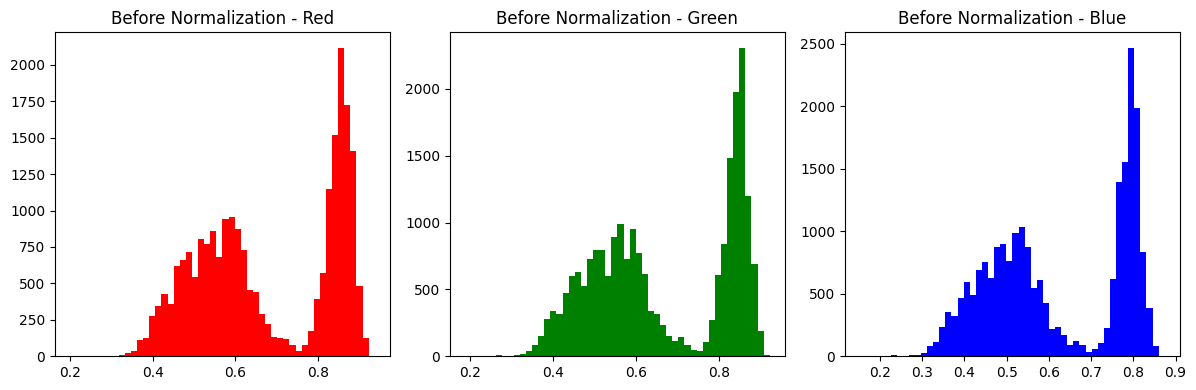

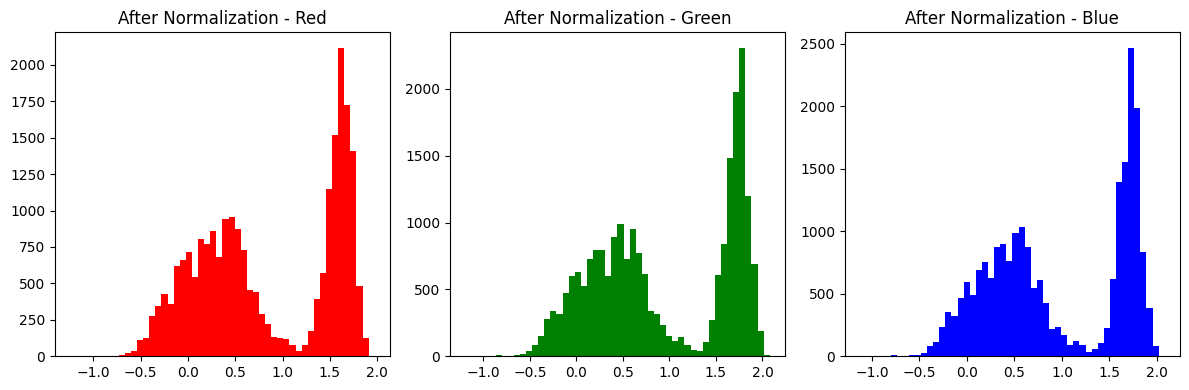

In [26]:
# Define transforms
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], #values used in pretraining 
    std=[0.229, 0.224, 0.225]
)

# Apply transformations
tensor_img = to_tensor(img)
normalized_img = normalize(tensor_img)

# Plot histograms
def plot_histogram(tensor, title):
    plt.figure(figsize=(12, 4))
    channels = ['Red', 'Green', 'Blue']
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.hist(tensor[i].flatten().numpy(), bins=50, color=channels[i].lower())
        plt.title(f'{title} - {channels[i]}')
    plt.tight_layout()
    plt.show()

plot_histogram(tensor_img, "Before Normalization")
plot_histogram(normalized_img, "After Normalization")

In [34]:
# Für Training & Validierung (mit Augmentation)
train_val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Für Test (deterministisch)
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),  # statt RandomCrop
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
# Datensätze separat laden
full_dataset_train_val = datasets.ImageFolder(
    root=os.path.join(BASE, "dataset"), transform=train_val_transform)

full_dataset_test = datasets.ImageFolder(
    root=os.path.join(BASE, "dataset"), transform=test_transform)


In [36]:
# Aufteilen
total_size = len(full_dataset_train_val)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Split-Indices
generator = torch.Generator().manual_seed(42)
train_val_indices = torch.randperm(total_size, generator=generator)

# Subsets (verwende die gleichen Indices!)
train_indices = train_val_indices[:train_size]
val_indices = train_val_indices[train_size:train_size + val_size]
test_indices = train_val_indices[train_size + val_size:]

# Trainings- & Validierungssets mit augmentierten Daten
train_dataset = torch.utils.data.Subset(full_dataset_train_val, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset_train_val, val_indices)

# Testset mit deterministischen Daten
test_dataset = torch.utils.data.Subset(full_dataset_test, test_indices)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [28]:
# Load dataset
dataset = datasets.ImageFolder(root=os.path.join(BASE, "dataset"), transform=transform)

# Sizes
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # Ensures full coverage

# Split dataset
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=generator)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [38]:
model = models.resnet18(pretrained=True)

# Modify the final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 2)

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [41]:
# Training loop with validation
num_epochs = 10
train_losses = []
val_losses = []

In [42]:
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_losses.append(running_train_loss)

    # Validation loop
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    val_losses.append(running_val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {running_train_loss:.4f} | Val Loss: {running_val_loss:.4f}")



Epoch 1 | Train Loss: 248.0578 | Val Loss: 39.7599
Epoch 2 | Train Loss: 179.4073 | Val Loss: 34.0386
Epoch 3 | Train Loss: 157.9879 | Val Loss: 30.4239
Epoch 4 | Train Loss: 141.7994 | Val Loss: 29.9038
Epoch 5 | Train Loss: 138.8261 | Val Loss: 23.9064
Epoch 6 | Train Loss: 131.6369 | Val Loss: 21.2156
Epoch 7 | Train Loss: 123.3263 | Val Loss: 22.2111
Epoch 8 | Train Loss: 117.5811 | Val Loss: 20.8033
Epoch 9 | Train Loss: 115.8110 | Val Loss: 21.6955
Epoch 10 | Train Loss: 109.9393 | Val Loss: 27.1911


In [43]:
# Save model
torch.save(model.state_dict(), os.path.join(BASE, "models",  "resnet18_pitting_not_simplified.pth"))

In [ ]:
losses = {
    "train": train_losses, 
    "val": val_losses
}

# path 
save_path = os.path.join(BASE, "models", "losses.pkl")

# save
with open(save_path, "wb") as f:
    pickle.dump(losses, f)

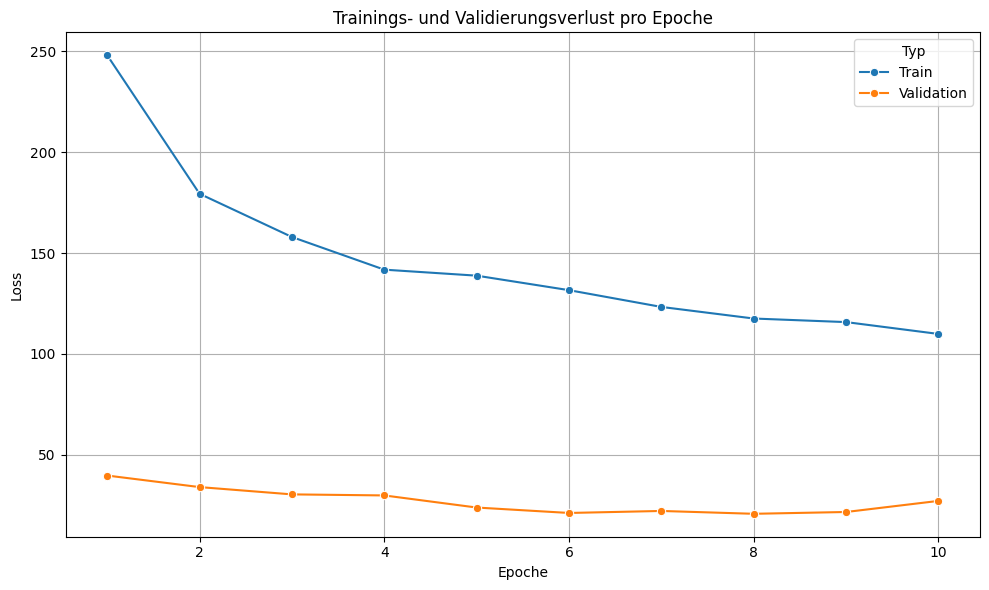

In [51]:
epochs = list(range(1, len(losses["train"]) + 1))
df = pd.DataFrame({
    "Epoch": epochs * 2,
    "Loss": losses["train"] + losses["val"],
    "Typ": ["Train"] * len(losses["train"]) + ["Validation"] * len(losses["val"])
})

# Lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Epoch", y="Loss", hue="Typ", marker="o")
plt.title("Trainings- und Validierungsverlust pro Epoche")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#load model
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 2 classes
model.load_state_dict(torch.load(os.path.join(BASE, "models/resnet18_pitting_not_simplified.pth")))
model.to(device)  # Send model to GPU/CPU


/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [55]:
model.eval()  # Set to evaluation mode for inference

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [56]:
# Final evaluation on the test set
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test Accuracy: 0.9926244622003688
Confusion Matrix:
[[1654   18]
 [   6 1576]]


<Axes: >

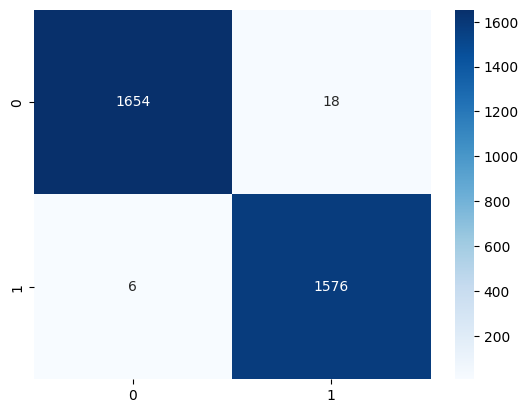

In [57]:
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt="d", cmap="Blues") 


In [79]:
y_true = all_labels
y_pred = all_preds

# Metrics
print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Test Accuracy: 0.9926244622003688

Confusion Matrix:
[[1654   18]
 [   6 1576]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9964    0.9892    0.9928      1672
           1     0.9887    0.9962    0.9924      1582

    accuracy                         0.9926      3254
   macro avg     0.9925    0.9927    0.9926      3254
weighted avg     0.9927    0.9926    0.9926      3254



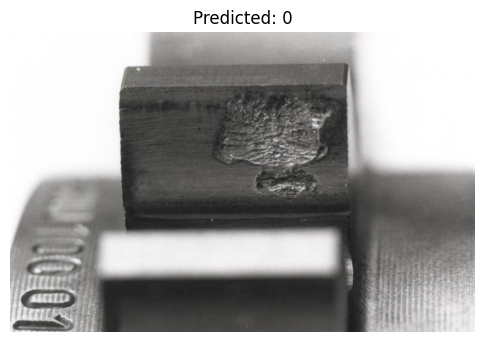

In [142]:
# Load the image
#image_path = os.path.join(BASE, "data/KGT_pitting_simplified/P (652).png") 
image_path= "/Users/janikwahrheit/Downloads/Oel_pit_h.jpg"

image = Image.open(image_path)


# Apply the transformations
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension (1, C, H, W)

# Move the image to the same device as the model
image_tensor = image_tensor.to(device)

# Make the prediction
with torch.no_grad():  # Turn off gradients to save memory
    outputs = model(image_tensor)

# Get the predicted class (the index of the max value in the output)
_, predicted_class = torch.max(outputs, 1)


# Display the image and the predicted label
plt.figure(figsize=(6, 6))
plt.imshow(np.array(image))  # Convert the image to a numpy array for displaying
plt.title(f'Predicted: {predicted_class.item()}')
plt.axis('off')  
plt.show()

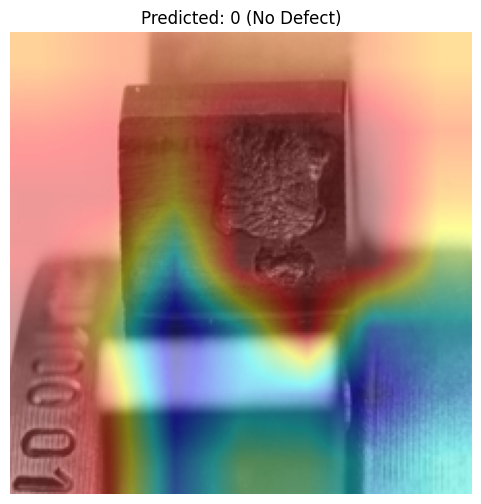

In [139]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) 
])

input_tensor = transform(image).unsqueeze(0).to(device)
#Hook for gradients
gradients = []



def save_gradient(grad):
    gradients.append(grad)

#Forward hook for activations
activations = []

def forward_hook(module, input, output):
    activations.append(output)
    output.register_hook(save_gradient)

# Register the hook to the last conv layer of ResNet18
target_layer = model.layer4
hook = target_layer.register_forward_hook(forward_hook)

# Forward pass
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

#Backward pass for Grad-CAM 
model.zero_grad()
output[0, pred_class].backward()

# Get activations and gradients 
grads_val = gradients[0][0].cpu().detach().numpy()  # (C, H, W)
acts_val = activations[0][0].cpu().detach().numpy()  # (C, H, W)

# Compute the weights and CAM
weights = np.mean(grads_val, axis=(1, 2))  # Global average pooling
cam = np.zeros(acts_val.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * acts_val[i, :, :]

#Normalize and resize the CAM 
cam = np.maximum(cam, 0)  # ReLU
cam = cam - cam.min()
cam = cam / cam.max()
cam = cv2.resize(cam, (224, 224))

# Overlay the heatmap on the image 
img_np = np.array(image.resize((224, 224)))  # Original image
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
inverted_heatmap = cv2.bitwise_not(heatmap)
overlay = heatmap * 0.4 + img_np * 0.6
overlay = np.uint8(overlay)

# Show the result 
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title(f"Predicted: {pred_class} ({'Pitting' if pred_class == 1 else 'No Defect'})")
plt.axis('off')
plt.show()

# Cleanup
hook.remove()